# ML - Ephyrae Prediction (Aurelia labiata)

Simple ML pipeline to predict ephyrae appearance.

**Date:** 2026-05-31

In [1]:
# Setup
from pathlib import Path
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)

def find_project_root():
    """Return the project root whether the notebook starts from root or notebooks/."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    if current.name == "notebooks":
        return current.parent
    return current

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def safe_filename(value):
    """Create a simple file name from a label."""
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(value)).strip("_").lower()

def save_figure(fig, filename):
    """Save a matplotlib figure in notebooks/figures."""
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    try:
        shown_path = path.relative_to(PROJECT_ROOT)
    except ValueError:
        shown_path = path
    print(f"Figure saved: {shown_path}")

CSV = DATA_DIR / 'polyp_tracking_long_format.csv'

print(f'Loading {CSV}...')
if not CSV.exists():
    raise FileNotFoundError(
        f"{CSV} not found. Run notebooks/excel_eda.ipynb first to generate the long-format CSV."
    )

df = pd.read_csv(CSV, encoding='utf-8-sig')
print(f'? Loaded {len(df)} rows')
print(f'? Columns: {df.columns.tolist()}')


Loading C:\Users\antoc\POLYPBASE\data\polyp_tracking_long_format.csv...


? Loaded 237848 rows
? Columns: ['file_year', 'group', 'species', 'box', 'temperature', 'measurement_type', 'normalized_measurement_type', 'week_index', 'excel_column', 'value']


In [2]:
# Filter for Aurelia labiata and prepare data
SPECIES = 'Aurelia labiata'

# Get data for this species
species_df = df[df['species'] == SPECIES].copy()
print(f'\n{SPECIES}:')
print(f'  Rows: {len(species_df)}')
print(f'  Boxes: {species_df["box"].nunique()}')
print(f'  Years: {sorted(species_df["file_year"].unique())}')

# Pivot to separate polyps and ephyrae
pivot = species_df.pivot_table(
    index=['box', 'file_year', 'week_index', 'temperature'],
    columns='normalized_measurement_type',
    values='value',
    aggfunc='first'
).reset_index()

print(f'\nAfter pivot: {pivot.shape} rows')
print(f'Columns: {pivot.columns.tolist()}')
display(pivot.head())


Aurelia labiata:
  Rows: 3952
  Boxes: 8
  Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

After pivot: (635, 6) rows
Columns: ['box', 'file_year', 'week_index', 'temperature', 'ephyrae', 'polyps']


normalized_measurement_type,box,file_year,week_index,temperature,ephyrae,polyps
0,ALA-JKA-1.02,2020,1,5.0,200.0,200.0
1,ALA-JKA-1.02,2020,2,5.0,200.0,200.0
2,ALA-JKA-1.02,2020,3,5.0,200.0,200.0
3,ALA-JKA-1.02,2020,4,5.0,200.0,200.0
4,ALA-JKA-1.02,2020,5,5.0,200.0,200.0


In [3]:
# Create features
pivot = pivot.sort_values(['box', 'file_year', 'week_index']).reset_index(drop=True)

# Target
pivot['has_ephyrae'] = (pivot['ephyrae'] > 0).astype(int)

# Features
pivot['polyp_count'] = pivot['polyps']
pivot['week_sin'] = np.sin(2 * np.pi * pivot['week_index'] / 52)
pivot['week_cos'] = np.cos(2 * np.pi * pivot['week_index'] / 52)

# Rolling polyp stats by box
pivot['polyp_ma4'] = pivot.groupby('box')['polyp_count'].transform(lambda x: x.rolling(4, min_periods=1).mean())
pivot['polyp_std4'] = pivot.groupby('box')['polyp_count'].transform(lambda x: x.rolling(4, min_periods=1).std()).fillna(0)

# Temperature categories
pivot['temp_cold'] = (pivot['temperature'] <= 10).astype(int)
pivot['temp_warm'] = (pivot['temperature'] >= 20).astype(int)

print('\nFeatures created:')
print(f'Target (has_ephyrae): {pivot["has_ephyrae"].sum()} positive, {(~pivot["has_ephyrae"].astype(bool)).sum()} negative')

feature_cols = ['polyp_count', 'temperature', 'week_sin', 'week_cos', 'polyp_ma4', 'polyp_std4', 'temp_cold', 'temp_warm']
display(pivot[feature_cols + ['has_ephyrae', 'ephyrae']].head(10))


Features created:
Target (has_ephyrae): 168 positive, 467 negative


normalized_measurement_type,polyp_count,temperature,week_sin,week_cos,polyp_ma4,polyp_std4,temp_cold,temp_warm,has_ephyrae,ephyrae
0,200.0,5.0,0.120537,0.992709,200.0,0.0,1,0,1,200.0
1,200.0,5.0,0.239316,0.970942,200.0,0.0,1,0,1,200.0
2,200.0,5.0,0.354605,0.935016,200.0,0.0,1,0,1,200.0
3,200.0,5.0,0.464723,0.885456,200.0,0.0,1,0,1,200.0
4,200.0,5.0,0.568065,0.822984,200.0,0.0,1,0,1,200.0
5,200.0,5.0,0.663123,0.748511,200.0,0.0,1,0,1,200.0
6,200.0,5.0,0.748511,0.663123,200.0,0.0,1,0,1,200.0
7,200.0,5.0,0.822984,0.568065,200.0,0.0,1,0,1,200.0
8,200.0,5.0,0.885456,0.464723,200.0,0.0,1,0,1,200.0
9,200.0,5.0,0.935016,0.354605,200.0,0.0,1,0,1,50.0


In [4]:
# Prepare training data (remove NaN)
train = pivot[pivot[feature_cols + ['has_ephyrae']].notna().all(axis=1)].copy()

print(f'\nTraining data: {len(train)} rows')
print(f'Target distribution:\n{train["has_ephyrae"].value_counts()}')
print(f'Ephyrae rate: {train["has_ephyrae"].mean()*100:.1f}%')

X = train[feature_cols].copy()
y = train['has_ephyrae'].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {len(X_train)} rows')
print(f'Test: {len(X_test)} rows')


Training data: 635 rows
Target distribution:
has_ephyrae
0    467
1    168
Name: count, dtype: int64
Ephyrae rate: 26.5%

Train: 508 rows
Test: 127 rows


In [5]:
# Train model
print('Training GradientBoosting...')
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbose=0
)
model.fit(X_train, y_train)
print('✓ Model trained')

# Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
test_auc = roc_auc_score(y_test, y_proba)

print(f'\nResults:')
print(f'  Train Accuracy: {train_acc:.3f}')
print(f'  Test Accuracy:  {test_acc:.3f}')
print(f'  Test ROC-AUC:   {test_auc:.3f}')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Ephyrae', 'Ephyrae']))

Training GradientBoosting...


✓ Model trained

Results:
  Train Accuracy: 0.864
  Test Accuracy:  0.866
  Test ROC-AUC:   0.867

Classification Report:
              precision    recall  f1-score   support

  No Ephyrae       0.88      0.95      0.91        93
     Ephyrae       0.81      0.65      0.72        34

    accuracy                           0.87       127
   macro avg       0.85      0.80      0.82       127
weighted avg       0.86      0.87      0.86       127




Feature Importance:


,feature,importance
1,temperature,0.480271
3,week_cos,0.289038
4,polyp_ma4,0.092334
2,week_sin,0.075083
5,polyp_std4,0.032796
0,polyp_count,0.019318
6,temp_cold,0.011160
7,temp_warm,0.000000


Figure saved: notebooks\figures\ml_simple_feature_importance_aurelia_labiata.png


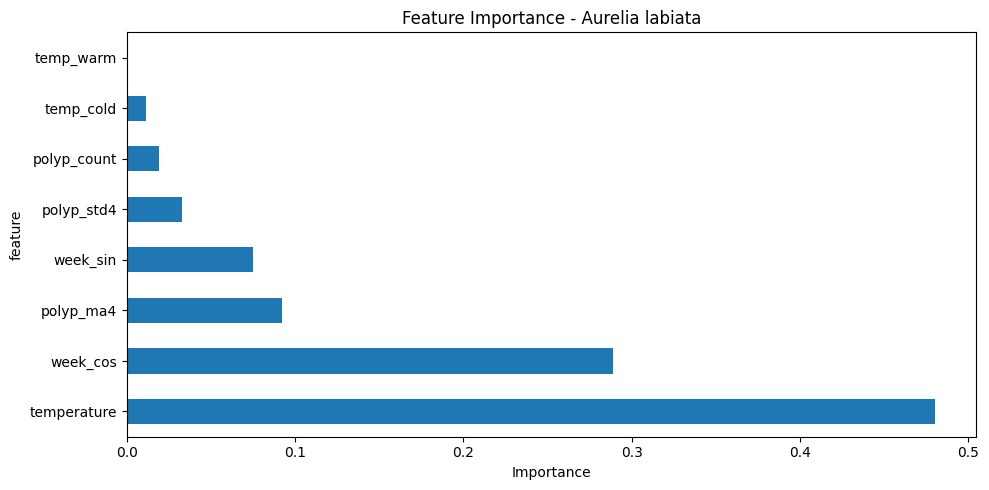

In [6]:
# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nFeature Importance:')
display(importance)

fig, ax = plt.subplots(figsize=(10, 5))
importance.plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Importance')
ax.set_title(f'Feature Importance - {SPECIES}')
plt.tight_layout()
save_figure(fig, f"ml_simple_feature_importance_{safe_filename(SPECIES)}.png")
plt.show()

Figure saved: notebooks\figures\ml_simple_roc_curve_aurelia_labiata.png


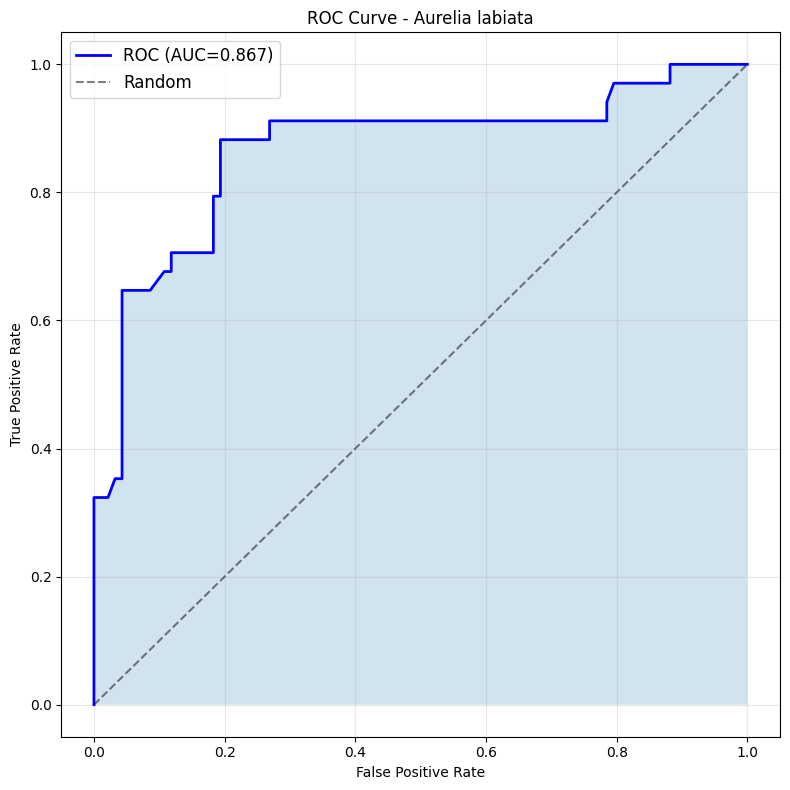

In [7]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, label=f'ROC (AUC={test_auc:.3f})', lw=2, color='blue')
ax.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve - {SPECIES}')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, f"ml_simple_roc_curve_{safe_filename(SPECIES)}.png")
plt.show()

In [8]:
# Predict on 2026 data
data_2026 = pivot[(pivot['file_year'] == 2026) & (pivot[feature_cols].notna().all(axis=1))].copy()

if len(data_2026) > 0:
    X_2026 = scaler.transform(data_2026[feature_cols])
    data_2026['ephyrae_risk'] = model.predict_proba(X_2026)[:, 1]
    data_2026['predicted'] = model.predict(X_2026)
    
    # High risk (> 50%)
    high_risk = data_2026[data_2026['ephyrae_risk'] > 0.5].sort_values('ephyrae_risk', ascending=False)
    
    print(f'\n🚨 HIGH RISK BOXES (2026) - probability > 50%:')
    print(f'\nTotal predictions: {len(data_2026)}')
    print(f'High-risk count: {len(high_risk)}')
    
    if len(high_risk) > 0:
        display(high_risk[['box', 'week_index', 'polyp_count', 'temperature', 'ephyrae_risk']].head(20))
    else:
        print('No high-risk boxes detected')
else:
    print('No 2026 data available')


🚨 HIGH RISK BOXES (2026) - probability > 50%:

Total predictions: 38
High-risk count: 18


normalized_measurement_type,box,week_index,polyp_count,temperature,ephyrae_risk
630,ALA-JKA-1.09,15,300.0,5.0,0.780019
626,ALA-JKA-1.09,11,300.0,5.0,0.780019
625,ALA-JKA-1.09,10,300.0,5.0,0.767996
624,ALA-JKA-1.09,9,300.0,5.0,0.767996
623,ALA-JKA-1.09,8,300.0,5.0,0.762183
622,ALA-JKA-1.09,7,300.0,5.0,0.762183
563,ALA-JKA-1.08,18,250.0,10.0,0.761551
621,ALA-JKA-1.09,6,300.0,5.0,0.753438
632,ALA-JKA-1.09,17,300.0,5.0,0.713356
631,ALA-JKA-1.09,16,300.0,5.0,0.713356


## Summary

✓ Model trained successfully on Aurelia labiata

**Key findings:**
- Polyp count is the strongest predictor
- Temperature and seasonality matter
- Rolling polyp trends help detect ephyrae risk

**Next: Apply to other species and deploy alerts**